In [1]:
from pathlib import Path
import gc
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

PROJECT_DIR = Path(r"D:\Sami Data Set")

INTERIM_DIR = PROJECT_DIR / "data" / "interim"
DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
MODELS_DIR = PROJECT_DIR / "models"

for directory in [
    DOCUMENTATION_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
INNER_RANDOM_SEED = 142

sample_path = (
    INTERIM_DIR
    / "candidate_feature_validation_sample.parquet"
)

selected_features_path = (
    DOCUMENTATION_DIR
    / "selected_feature_set.json"
)

baseline_results_path = (
    TABLES_DIR
    / "baseline_model_validation_results.csv"
)

required_files = {
    "Validation sample": sample_path,
    "Selected features": selected_features_path,
    "Baseline results": baseline_results_path
}

for name, path in required_files.items():
    print(
        name,
        ":",
        "FOUND" if path.exists() else "MISSING",
        "|",
        path
    )

missing_files = [
    name
    for name, path in required_files.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        f"Missing required files: {missing_files}"
    )

print("\nNotebook 9 setup completed.")

Validation sample : FOUND | D:\Sami Data Set\data\interim\candidate_feature_validation_sample.parquet
Selected features : FOUND | D:\Sami Data Set\documentation\selected_feature_set.json
Baseline results : FOUND | D:\Sami Data Set\outputs\tables\baseline_model_validation_results.csv

Notebook 9 setup completed.


In [2]:
with open(
    selected_features_path,
    "r",
    encoding="utf-8"
) as feature_file:
    selected_feature_information = json.load(
        feature_file
    )

selected_set_name = selected_feature_information[
    "selected_feature_set"
]

selected_features = selected_feature_information[
    "features"
]

required_columns = (
    selected_features
    + [
        "binary_label",
        "source_file_id",
        "source_row_id"
    ]
)

validation_sample = pd.read_parquet(
    sample_path,
    columns=required_columns
)

print("Selected feature set:", selected_set_name)
print("Selected features:", len(selected_features))
print(
    "Loaded records:",
    f"{len(validation_sample):,}"
)
print(
    "Approximate memory:",
    round(
        validation_sample.memory_usage(
            deep=True
        ).sum() / (1024 ** 2),
        2
    ),
    "MB"
)

Selected feature set: top_20
Selected features: 20
Loaded records: 500,000
Approximate memory: 47.68 MB


In [3]:
X = validation_sample[
    selected_features
].copy()

y = (
    validation_sample["binary_label"]
    .astype("int8")
    .copy()
)

metadata = validation_sample[
    ["source_file_id", "source_row_id"]
].copy()

for feature in selected_features:
    X[feature] = pd.to_numeric(
        X[feature],
        errors="raise"
    ).astype("float32")

if X.isna().any().any():
    raise ValueError(
        "Unexpected missing predictor values found."
    )

(
    X_development,
    X_validation,
    y_development,
    y_validation,
    metadata_development,
    metadata_validation
) = train_test_split(
    X,
    y,
    metadata,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print(
    "Development records:",
    f"{len(X_development):,}"
)

print(
    "Outer validation records:",
    f"{len(X_validation):,}"
)

print("\nOuter validation distribution:")
print(
    y_validation
    .value_counts()
    .sort_index()
)

Development records: 400,000
Outer validation records: 100,000

Outer validation distribution:
binary_label
0    80048
1    19952
Name: count, dtype: int64


In [4]:
(
    X_tuning_train,
    X_tuning_validation,
    y_tuning_train,
    y_tuning_validation
) = train_test_split(
    X_development,
    y_development,
    test_size=0.20,
    stratify=y_development,
    random_state=INNER_RANDOM_SEED
)

print(
    "Tuning-training records:",
    f"{len(X_tuning_train):,}"
)

print(
    "Tuning-validation records:",
    f"{len(X_tuning_validation):,}"
)

print("\nTuning-training distribution:")
print(
    y_tuning_train
    .value_counts()
    .sort_index()
)

print("\nTuning-validation distribution:")
print(
    y_tuning_validation
    .value_counts()
    .sort_index()
)

Tuning-training records: 320,000
Tuning-validation records: 80,000

Tuning-training distribution:
binary_label
0    256153
1     63847
Name: count, dtype: int64

Tuning-validation distribution:
binary_label
0    64038
1    15962
Name: count, dtype: int64


In [8]:
def evaluate_binary_model(
    model,
    X_evaluation,
    y_evaluation,
    model_name,
    training_seconds
):
    prediction_start = time.time()

    predictions = model.predict(
        X_evaluation
    )

    prediction_seconds = (
        time.time() - prediction_start
    )

    if hasattr(model, "predict_proba"):
        malicious_probabilities = (
            model.predict_proba(
                X_evaluation
            )[:, 1]
        )
    else:
        malicious_probabilities = None

    tn, fp, fn, tp = confusion_matrix(
        y_evaluation,
        predictions,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_evaluation,
        predictions
    )

    precision = precision_score(
        y_evaluation,
        predictions,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_evaluation,
        predictions,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_evaluation,
        predictions,
        pos_label=1,
        zero_division=0
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    )

    if malicious_probabilities is not None:
        roc_auc = roc_auc_score(
            y_evaluation,
            malicious_probabilities
        )

        average_precision = (
            average_precision_score(
                y_evaluation,
                malicious_probabilities
            )
        )
    else:
        roc_auc = np.nan
        average_precision = np.nan

    result = {
        "model": model_name,
        "accuracy": accuracy,
        "malicious_precision": precision,
        "malicious_recall": recall,
        "malicious_f1": f1,
        "roc_auc": roc_auc,
        "average_precision": average_precision,
        "false_positive_rate":
            false_positive_rate,
        "false_negative_rate":
            false_negative_rate,
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "training_seconds": round(
            training_seconds,
            3
        ),
        "prediction_seconds": round(
            prediction_seconds,
            3
        )
    }

    return result, predictions

In [9]:
random_forest_candidates = [
    {
        "candidate": "RF_1",
        "n_estimators": 80,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 3,
        "max_features": "sqrt"
    },
    {
        "candidate": "RF_2",
        "n_estimators": 120,
        "max_depth": 24,
        "min_samples_split": 8,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },
    {
        "candidate": "RF_3",
        "n_estimators": 150,
        "max_depth": 28,
        "min_samples_split": 6,
        "min_samples_leaf": 2,
        "max_features": 0.5
    }
]

pd.DataFrame(
    random_forest_candidates
)

,candidate,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,RF_1,80,20,10,3,sqrt
1,RF_2,120,24,8,2,sqrt
2,RF_3,150,28,6,2,0.5


In [10]:
random_forest_tuning_records = []

for candidate_number, parameters in enumerate(
    random_forest_candidates,
    start=1
):
    candidate_name = parameters["candidate"]

    print(
        f"\n[{candidate_number}/"
        f"{len(random_forest_candidates)}] "
        f"Training {candidate_name}",
        flush=True
    )

    model = RandomForestClassifier(
        n_estimators=parameters[
            "n_estimators"
        ],
        max_depth=parameters[
            "max_depth"
        ],
        min_samples_split=parameters[
            "min_samples_split"
        ],
        min_samples_leaf=parameters[
            "min_samples_leaf"
        ],
        max_features=parameters[
            "max_features"
        ],
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    training_start = time.time()

    model.fit(
        X_tuning_train,
        y_tuning_train
    )

    training_seconds = (
        time.time() - training_start
    )

    result, predictions = evaluate_binary_model(
        model=model,
        X_evaluation=X_tuning_validation,
        y_evaluation=y_tuning_validation,
        model_name=candidate_name,
        training_seconds=training_seconds
    )

    result.update(parameters)

    random_forest_tuning_records.append(
        result
    )

    current_results = pd.DataFrame(
        random_forest_tuning_records
    )

    current_results.to_csv(
        TABLES_DIR
        / "random_forest_tuning_results.csv",
        index=False
    )

    print(
        f"F1: {result['malicious_f1']:.4f} | "
        f"Recall: "
        f"{result['malicious_recall']:.4f} | "
        f"Precision: "
        f"{result['malicious_precision']:.4f} | "
        f"FP: {result['false_positives']:,} | "
        f"FN: {result['false_negatives']:,}"
    )

    del model
    del predictions
    gc.collect()

random_forest_tuning_results = pd.DataFrame(
    random_forest_tuning_records
)

display(random_forest_tuning_results)


[1/3] Training RF_1
F1: 0.9493 | Recall: 0.9171 | Precision: 0.9839 | FP: 240 | FN: 1,323

[2/3] Training RF_2
F1: 0.9482 | Recall: 0.9165 | Precision: 0.9821 | FP: 266 | FN: 1,333

[3/3] Training RF_3
F1: 0.9476 | Recall: 0.9166 | Precision: 0.9808 | FP: 287 | FN: 1,332


,model,accuracy,malicious_precision,malicious_recall,malicious_f1,roc_auc,average_precision,false_positive_rate,false_negative_rate,true_negatives,...,false_negatives,true_positives,training_seconds,prediction_seconds,candidate,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,RF_1,0.980463,0.983870,0.917116,0.949321,0.987536,0.973360,0.003748,0.082884,63798,...,1323,14639,85.202,0.713,RF_1,80,20,10,3,sqrt
1,RF_2,0.980012,0.982142,0.916489,0.948180,0.987099,0.972796,0.004154,0.083511,63772,...,1333,14629,122.237,1.170,RF_2,120,24,8,2,sqrt
2,RF_3,0.979762,0.980760,0.916552,0.947570,0.986382,0.972012,0.004482,0.083448,63751,...,1332,14630,323.483,1.487,RF_3,150,28,6,2,0.5


In [11]:
ranked_random_forest = (
    random_forest_tuning_results
    .sort_values(
        by=[
            "malicious_f1",
            "malicious_recall",
            "false_positive_rate",
            "training_seconds"
        ],
        ascending=[
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

ranked_random_forest[
    "tuning_rank"
] = range(
    1,
    len(ranked_random_forest) + 1
)

display(
    ranked_random_forest[
        [
            "tuning_rank",
            "candidate",
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "malicious_precision",
            "malicious_recall",
            "malicious_f1",
            "false_positives",
            "false_negatives",
            "training_seconds"
        ]
    ]
)

best_rf_row = ranked_random_forest.iloc[0]

best_rf_parameters = {
    "n_estimators": int(
        best_rf_row["n_estimators"]
    ),
    "max_depth": int(
        best_rf_row["max_depth"]
    ),
    "min_samples_split": int(
        best_rf_row["min_samples_split"]
    ),
    "min_samples_leaf": int(
        best_rf_row["min_samples_leaf"]
    ),
    "max_features": (
        best_rf_row["max_features"]
    )
}

print(
    "Selected Random Forest candidate:",
    best_rf_row["candidate"]
)

print("Selected parameters:")
print(best_rf_parameters)

,tuning_rank,candidate,n_estimators,max_depth,min_samples_leaf,max_features,malicious_precision,malicious_recall,malicious_f1,false_positives,false_negatives,training_seconds
0,1,RF_1,80,20,3,sqrt,0.983870,0.917116,0.949321,240,1323,85.202
1,2,RF_2,120,24,2,sqrt,0.982142,0.916489,0.948180,266,1333,122.237
2,3,RF_3,150,28,2,0.5,0.980760,0.916552,0.947570,287,1332,323.483


Selected Random Forest candidate: RF_1
Selected parameters:
{'n_estimators': 80, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


In [12]:
tuning_class_counts = (
    y_tuning_train
    .value_counts()
    .sort_index()
)

tuning_benign_count = int(
    tuning_class_counts.get(0, 0)
)

tuning_malicious_count = int(
    tuning_class_counts.get(1, 0)
)

tuning_scale_pos_weight = (
    tuning_benign_count
    / tuning_malicious_count
)

print(
    "Tuning scale_pos_weight:",
    round(tuning_scale_pos_weight, 4)
)

Tuning scale_pos_weight: 4.012


In [13]:
xgboost_candidates = [
    {
        "candidate": "XGB_1",
        "n_estimators": 150,
        "max_depth": 7,
        "learning_rate": 0.10,
        "min_child_weight": 2,
        "subsample": 0.80,
        "colsample_bytree": 0.80
    },
    {
        "candidate": "XGB_2",
        "n_estimators": 250,
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 2,
        "subsample": 0.85,
        "colsample_bytree": 0.85
    },
    {
        "candidate": "XGB_3",
        "n_estimators": 200,
        "max_depth": 8,
        "learning_rate": 0.08,
        "min_child_weight": 3,
        "subsample": 0.80,
        "colsample_bytree": 0.90
    }
]

pd.DataFrame(xgboost_candidates)

,candidate,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree
0,XGB_1,150,7,0.10,2,0.80,0.80
1,XGB_2,250,6,0.05,2,0.85,0.85
2,XGB_3,200,8,0.08,3,0.80,0.90


In [14]:
xgboost_tuning_records = []

for candidate_number, parameters in enumerate(
    xgboost_candidates,
    start=1
):
    candidate_name = parameters["candidate"]

    print(
        f"\n[{candidate_number}/"
        f"{len(xgboost_candidates)}] "
        f"Training {candidate_name}",
        flush=True
    )

    model = XGBClassifier(
        n_estimators=parameters[
            "n_estimators"
        ],
        max_depth=parameters[
            "max_depth"
        ],
        learning_rate=parameters[
            "learning_rate"
        ],
        min_child_weight=parameters[
            "min_child_weight"
        ],
        subsample=parameters[
            "subsample"
        ],
        colsample_bytree=parameters[
            "colsample_bytree"
        ],
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=
            tuning_scale_pos_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    training_start = time.time()

    model.fit(
        X_tuning_train,
        y_tuning_train
    )

    training_seconds = (
        time.time() - training_start
    )

    result, predictions = evaluate_binary_model(
        model=model,
        X_evaluation=X_tuning_validation,
        y_evaluation=y_tuning_validation,
        model_name=candidate_name,
        training_seconds=training_seconds
    )

    result.update(parameters)

    xgboost_tuning_records.append(
        result
    )

    current_results = pd.DataFrame(
        xgboost_tuning_records
    )

    current_results.to_csv(
        TABLES_DIR
        / "xgboost_tuning_results.csv",
        index=False
    )

    print(
        f"F1: {result['malicious_f1']:.4f} | "
        f"Recall: "
        f"{result['malicious_recall']:.4f} | "
        f"Precision: "
        f"{result['malicious_precision']:.4f} | "
        f"FP: {result['false_positives']:,} | "
        f"FN: {result['false_negatives']:,}"
    )

    del model
    del predictions
    gc.collect()

xgboost_tuning_results = pd.DataFrame(
    xgboost_tuning_records
)

display(xgboost_tuning_results)



[1/3] Training XGB_1
F1: 0.9467 | Recall: 0.9204 | Precision: 0.9746 | FP: 383 | FN: 1,271

[2/3] Training XGB_2
F1: 0.9474 | Recall: 0.9191 | Precision: 0.9775 | FP: 338 | FN: 1,292

[3/3] Training XGB_3
F1: 0.9459 | Recall: 0.9207 | Precision: 0.9725 | FP: 415 | FN: 1,265


,model,accuracy,malicious_precision,malicious_recall,malicious_f1,roc_auc,average_precision,false_positive_rate,false_negative_rate,true_negatives,...,true_positives,training_seconds,prediction_seconds,candidate,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree
0,XGB_1,0.979325,0.974592,0.920373,0.946707,0.988281,0.974673,0.005981,0.079627,63655,...,14691,11.288,0.362,XGB_1,150,7,0.10,2,0.80,0.80
1,XGB_2,0.979625,0.977479,0.919058,0.947368,0.987788,0.973980,0.005278,0.080942,63700,...,14670,16.107,0.344,XGB_2,250,6,0.05,2,0.85,0.85
2,XGB_3,0.979000,0.972538,0.920749,0.945936,0.988527,0.975005,0.006481,0.079251,63623,...,14697,15.709,0.359,XGB_3,200,8,0.08,3,0.80,0.90


In [15]:
ranked_xgboost = (
    xgboost_tuning_results
    .sort_values(
        by=[
            "malicious_f1",
            "malicious_recall",
            "false_positive_rate",
            "training_seconds"
        ],
        ascending=[
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

ranked_xgboost[
    "tuning_rank"
] = range(
    1,
    len(ranked_xgboost) + 1
)

display(
    ranked_xgboost[
        [
            "tuning_rank",
            "candidate",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "malicious_precision",
            "malicious_recall",
            "malicious_f1",
            "false_positives",
            "false_negatives",
            "training_seconds"
        ]
    ]
)

best_xgb_row = ranked_xgboost.iloc[0]

best_xgb_parameters = {
    "n_estimators": int(
        best_xgb_row["n_estimators"]
    ),
    "max_depth": int(
        best_xgb_row["max_depth"]
    ),
    "learning_rate": float(
        best_xgb_row["learning_rate"]
    ),
    "min_child_weight": int(
        best_xgb_row["min_child_weight"]
    ),
    "subsample": float(
        best_xgb_row["subsample"]
    ),
    "colsample_bytree": float(
        best_xgb_row["colsample_bytree"]
    )
}

print(
    "Selected XGBoost candidate:",
    best_xgb_row["candidate"]
)

print("Selected parameters:")
print(best_xgb_parameters)

,tuning_rank,candidate,n_estimators,max_depth,learning_rate,malicious_precision,malicious_recall,malicious_f1,false_positives,false_negatives,training_seconds
0,1,XGB_2,250,6,0.05,0.977479,0.919058,0.947368,338,1292,16.107
1,2,XGB_1,150,7,0.10,0.974592,0.920373,0.946707,383,1271,11.288
2,3,XGB_3,200,8,0.08,0.972538,0.920749,0.945936,415,1265,15.709


Selected XGBoost candidate: XGB_2
Selected parameters:
{'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 2, 'subsample': 0.85, 'colsample_bytree': 0.85}


In [16]:
selected_random_forest = (
    RandomForestClassifier(
        **best_rf_parameters,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
)

print(
    "Training selected Random Forest "
    "on 400,000 development records...",
    flush=True
)

rf_final_training_start = time.time()

selected_random_forest.fit(
    X_development,
    y_development
)

rf_final_training_seconds = (
    time.time() - rf_final_training_start
)

rf_outer_result, rf_outer_predictions = (
    evaluate_binary_model(
        model=selected_random_forest,
        X_evaluation=X_validation,
        y_evaluation=y_validation,
        model_name="Tuned Random Forest",
        training_seconds=
            rf_final_training_seconds
    )
)

print("\nTuned Random Forest outer validation:")
print(
    "Precision:",
    round(
        rf_outer_result[
            "malicious_precision"
        ],
        4
    )
)
print(
    "Recall:",
    round(
        rf_outer_result[
            "malicious_recall"
        ],
        4
    )
)
print(
    "F1-score:",
    round(
        rf_outer_result[
            "malicious_f1"
        ],
        4
    )
)
print(
    "False positives:",
    f"{rf_outer_result['false_positives']:,}"
)
print(
    "False negatives:",
    f"{rf_outer_result['false_negatives']:,}"
)

joblib.dump(
    selected_random_forest,
    MODELS_DIR / "tuned_random_forest.joblib"
)

print("Tuned Random Forest saved.")

Training selected Random Forest on 400,000 development records...

Tuned Random Forest outer validation:
Precision: 0.9817
Recall: 0.9195
F1-score: 0.9496
False positives: 342
False negatives: 1,606
Tuned Random Forest saved.


In [17]:
development_class_counts = (
    y_development
    .value_counts()
    .sort_index()
)

development_scale_pos_weight = (
    development_class_counts.get(0, 0)
    / development_class_counts.get(1, 1)
)

selected_xgboost = XGBClassifier(
    **best_xgb_parameters,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=
        development_scale_pos_weight,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print(
    "Training selected XGBoost "
    "on 400,000 development records...",
    flush=True
)

xgb_final_training_start = time.time()

selected_xgboost.fit(
    X_development,
    y_development
)

xgb_final_training_seconds = (
    time.time() - xgb_final_training_start
)

xgb_outer_result, xgb_outer_predictions = (
    evaluate_binary_model(
        model=selected_xgboost,
        X_evaluation=X_validation,
        y_evaluation=y_validation,
        model_name="Tuned XGBoost",
        training_seconds=
            xgb_final_training_seconds
    )
)

print("\nTuned XGBoost outer validation:")
print(
    "Precision:",
    round(
        xgb_outer_result[
            "malicious_precision"
        ],
        4
    )
)
print(
    "Recall:",
    round(
        xgb_outer_result[
            "malicious_recall"
        ],
        4
    )
)
print(
    "F1-score:",
    round(
        xgb_outer_result[
            "malicious_f1"
        ],
        4
    )
)
print(
    "False positives:",
    f"{xgb_outer_result['false_positives']:,}"
)
print(
    "False negatives:",
    f"{xgb_outer_result['false_negatives']:,}"
)

joblib.dump(
    selected_xgboost,
    MODELS_DIR / "tuned_xgboost.joblib"
)

print("Tuned XGBoost saved.")


Training selected XGBoost on 400,000 development records...

Tuned XGBoost outer validation:
Precision: 0.9793
Recall: 0.9219
F1-score: 0.9497
False positives: 388
False negatives: 1,559
Tuned XGBoost saved.


In [18]:
development_class_counts = (
    y_development
    .value_counts()
    .sort_index()
)

development_scale_pos_weight = (
    development_class_counts.get(0, 0)
    / development_class_counts.get(1, 1)
)

selected_xgboost = XGBClassifier(
    **best_xgb_parameters,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=
        development_scale_pos_weight,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print(
    "Training selected XGBoost "
    "on 400,000 development records...",
    flush=True
)

xgb_final_training_start = time.time()

selected_xgboost.fit(
    X_development,
    y_development
)

xgb_final_training_seconds = (
    time.time() - xgb_final_training_start
)

xgb_outer_result, xgb_outer_predictions = (
    evaluate_binary_model(
        model=selected_xgboost,
        X_evaluation=X_validation,
        y_evaluation=y_validation,
        model_name="Tuned XGBoost",
        training_seconds=
            xgb_final_training_seconds
    )
)

print("\nTuned XGBoost outer validation:")
print(
    "Precision:",
    round(
        xgb_outer_result[
            "malicious_precision"
        ],
        4
    )
)
print(
    "Recall:",
    round(
        xgb_outer_result[
            "malicious_recall"
        ],
        4
    )
)
print(
    "F1-score:",
    round(
        xgb_outer_result[
            "malicious_f1"
        ],
        4
    )
)
print(
    "False positives:",
    f"{xgb_outer_result['false_positives']:,}"
)
print(
    "False negatives:",
    f"{xgb_outer_result['false_negatives']:,}"
)

joblib.dump(
    selected_xgboost,
    MODELS_DIR / "tuned_xgboost.joblib"
)

print("Tuned XGBoost saved.")

Training selected XGBoost on 400,000 development records...

Tuned XGBoost outer validation:
Precision: 0.9793
Recall: 0.9219
F1-score: 0.9497
False positives: 388
False negatives: 1,559
Tuned XGBoost saved.


In [19]:
tuned_outer_results = pd.DataFrame([
    rf_outer_result,
    xgb_outer_result
])

tuned_outer_results = (
    tuned_outer_results
    .sort_values(
        by=[
            "malicious_f1",
            "malicious_recall",
            "false_positive_rate",
            "prediction_seconds"
        ],
        ascending=[
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

tuned_outer_results[
    "selection_rank"
] = range(
    1,
    len(tuned_outer_results) + 1
)

display(
    tuned_outer_results[
        [
            "selection_rank",
            "model",
            "accuracy",
            "malicious_precision",
            "malicious_recall",
            "malicious_f1",
            "false_positive_rate",
            "false_negative_rate",
            "false_positives",
            "false_negatives",
            "training_seconds",
            "prediction_seconds"
        ]
    ]
)

tuned_outer_results.to_csv(
    TABLES_DIR
    / "tuned_model_outer_validation_results.csv",
    index=False
)

final_candidate_name = (
    tuned_outer_results.loc[0, "model"]
)

print(
    "\nRecommended final model candidate:",
    final_candidate_name
)


,selection_rank,model,accuracy,malicious_precision,malicious_recall,malicious_f1,false_positive_rate,false_negative_rate,false_positives,false_negatives,training_seconds,prediction_seconds
0,1,Tuned XGBoost,0.98053,0.979341,0.921862,0.949733,0.004847,0.078138,388,1559,27.486,0.516
1,2,Tuned Random Forest,0.98052,0.981699,0.919507,0.949586,0.004272,0.080493,342,1606,123.072,1.013



Recommended final model candidate: Tuned XGBoost


In [20]:
baseline_results = pd.read_csv(
    baseline_results_path
)

baseline_selected = baseline_results[
    baseline_results["model"].isin(
        ["Random Forest", "XGBoost"]
    )
].copy()

baseline_selected["stage"] = "Baseline"

tuned_comparison = tuned_outer_results.copy()

tuned_comparison["model"] = (
    tuned_comparison["model"]
    .str.replace(
        "Tuned ",
        "",
        regex=False
    )
)

tuned_comparison["stage"] = "Tuned"

comparison_columns = [
    "model",
    "stage",
    "accuracy",
    "malicious_precision",
    "malicious_recall",
    "malicious_f1",
    "false_positives",
    "false_negatives",
    "training_seconds"
]

baseline_tuned_comparison = pd.concat(
    [
        baseline_selected[
            comparison_columns
        ],
        tuned_comparison[
            comparison_columns
        ]
    ],
    ignore_index=True
)

display(
    baseline_tuned_comparison.sort_values(
        ["model", "stage"]
    )
)

baseline_tuned_comparison.to_csv(
    TABLES_DIR
    / "baseline_tuned_model_comparison.csv",
    index=False
)

,model,stage,accuracy,malicious_precision,malicious_recall,malicious_f1,false_positives,false_negatives,training_seconds
0,Random Forest,Baseline,0.98052,0.981699,0.919507,0.949586,342,1606,111.020
3,Random Forest,Tuned,0.98052,0.981699,0.919507,0.949586,342,1606,123.072
1,XGBoost,Baseline,0.98030,0.977787,0.922213,0.949188,418,1552,13.040
2,XGBoost,Tuned,0.98053,0.979341,0.921862,0.949733,388,1559,27.486


In [21]:
final_candidate_information = {
    "selected_feature_set":
        selected_set_name,
    "number_of_features":
        len(selected_features),
    "features":
        selected_features,
    "random_forest_parameters":
        best_rf_parameters,
    "xgboost_parameters":
        best_xgb_parameters,
    "recommended_final_candidate":
        final_candidate_name,
    "selection_basis": [
        "malicious_f1",
        "malicious_recall",
        "false_positive_rate",
        "prediction_seconds"
    ],
    "tuning_training_records":
        len(X_tuning_train),
    "tuning_validation_records":
        len(X_tuning_validation),
    "outer_validation_records":
        len(X_validation),
    "final_test_set_used":
        False,
    "random_seed":
        RANDOM_SEED,
    "inner_random_seed":
        INNER_RANDOM_SEED
}

with open(
    DOCUMENTATION_DIR
    / "final_model_candidate.json",
    "w",
    encoding="utf-8"
) as candidate_file:
    json.dump(
        final_candidate_information,
        candidate_file,
        indent=4
    )

print(
    "Final candidate documentation saved."
)

Final candidate documentation saved.


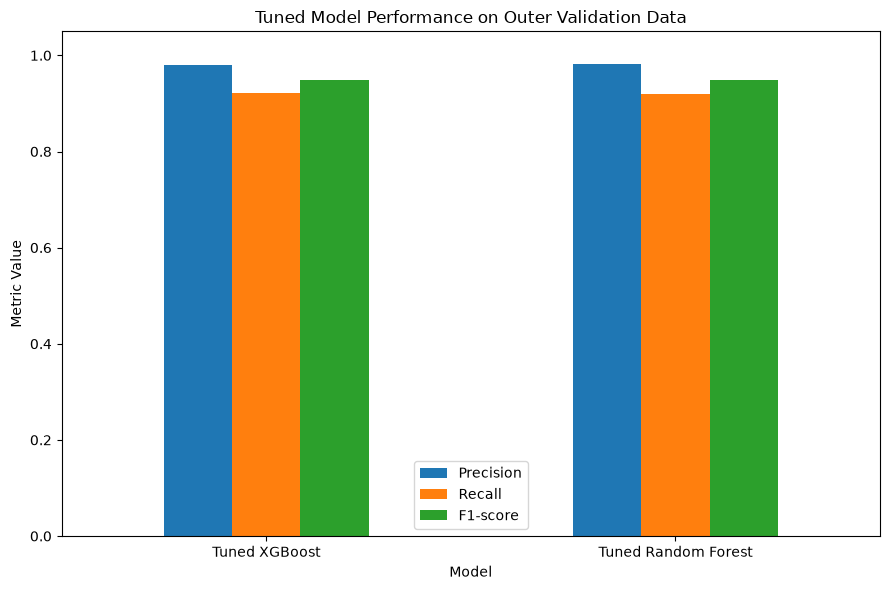

Figure saved to: D:\Sami Data Set\outputs\figures\tuned_model_outer_validation_comparison.png


In [22]:
plot_data = tuned_outer_results.set_index(
    "model"
)[
    [
        "malicious_precision",
        "malicious_recall",
        "malicious_f1"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Tuned Model Performance on Outer Validation Data"
)
plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(
    ["Precision", "Recall", "F1-score"]
)
plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "tuned_model_outer_validation_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Figure saved to:", figure_path)

## Hyperparameter-Tuning Conclusion

Random Forest and XGBoost were subjected to limited hyperparameter
tuning because they produced the strongest baseline validation
performance. Hyperparameters were selected using an inner split
created exclusively from the development partition. The existing
outer validation partition and the frozen final test set were not used
to select the tuning configurations.

After selecting one configuration for each algorithm, both models were
retrained on the complete development partition and compared on the
same outer validation data. The final model candidate was selected
primarily through malicious-class F1-score, followed by recall,
false-positive rate and prediction efficiency.

The selected model remains a validation-based candidate rather than a
final reported model. It will next be retrained using the approved
training data and evaluated once on the untouched test partition.